In [3]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from scripts.constants import PI, s2  # type: ignore
from scripts.utils import is_hermitian

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

In [2]:
X, Y = 100,100
lattice = Lattice(X, Y, pbc_x=True)
N= X*Y

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 1e-8
U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = 1.5 * t 
V = V0 * np.ones(lattice.X)
V_prime = V
H = Hamiltonian(t, mu, lattice, 
                U=U, V_prime=None,
                F0_init=0.1)
                # F_init=[0.1, -0.1, 0.1j, -0.1j])

In [3]:
energies = np.linspace(-3,3,1000) 
dos_values = 2 * H.dos(energies, eta=0.005)/ N

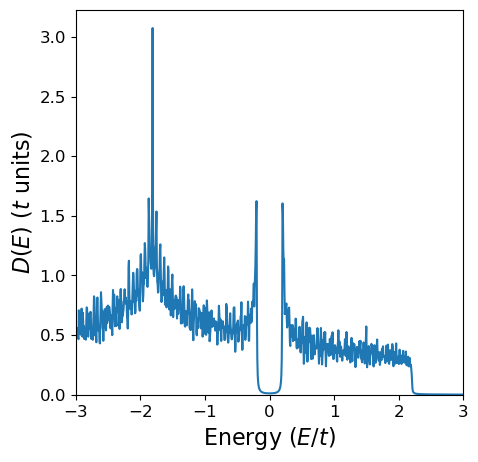

In [4]:
plt.figure(figsize=(5,5))
plt.plot(energies, dos_values)
plt.ylim(0, None)
plt.xlim(-3,3)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [5]:
X, Y = 100,100
lattice = Lattice(X, Y, pbc_x=True)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 1e-8
U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = 1 * t
V = V0 * np.ones(lattice.X)
V_prime = V
H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.1, -0.1, 0.1j, -0.1j])

energies = np.linspace(-3,3,1000) 
dos_interface, dos_bulk = H.dos_local(energies, eta=0.005,interface_width=15)

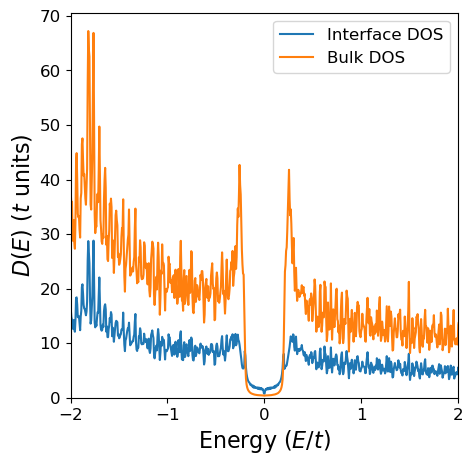

In [6]:
plt.figure(figsize=(5,5))
plt.plot(energies, dos_interface / H.lattice.Y, label='Interface DOS')
plt.plot(energies, dos_bulk / H.lattice.Y, label='Bulk DOS')
plt.ylim(0, None)
plt.xlim(-2, 2)
plt.xticks([-2, -1, 0, 1, 2])
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.show()

In [7]:
X, Y = 100,100
lattice = Lattice(X, Y, pbc_x=True)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 1e-8
U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = 1 * t
V = V0 * np.ones(lattice.X)
V_prime = V
H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.1, -0.1, 0.1, -0.1])

energies = np.linspace(-3,3,1000) 
dos_values_interface2, dos_values_bulk2 = H.dos_local(energies, eta=0.005, interface_width=15)

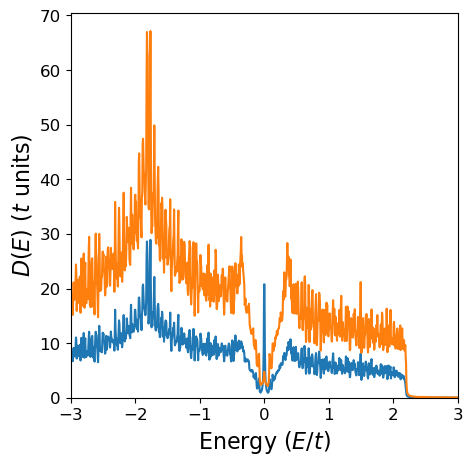

In [8]:
plt.figure(figsize=(5,5))
plt.plot(energies, dos_values_interface2 / H.lattice.Y, label='Interface DOS')
plt.plot(energies, dos_values_bulk2 / H.lattice.Y, label='Bulk DOS')
plt.ylim(0, None)
plt.xlim(-3,3)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [17]:
X, Y = 100,100
lattice = Lattice(X, Y, pbc_x=True)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 1e-8
U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = 1 * t
V = V0 * np.ones(lattice.X)
V_prime = V
H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.1, 0.1, -0.1, -0.1])

energies = np.linspace(-3,3,1000) 
dos_values4 = 2 * H.dos(energies, eta=0.005) / N

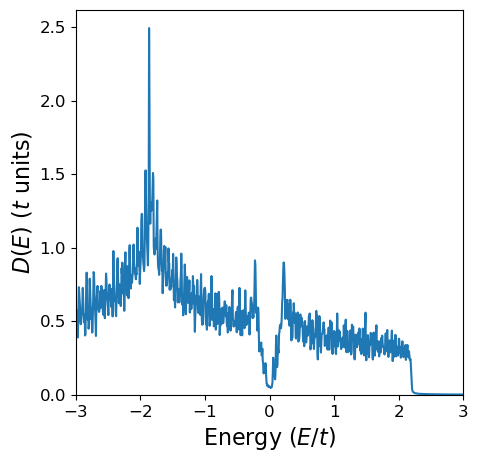

In [18]:
plt.figure(figsize=(5,5))
plt.plot(energies, dos_values4)
plt.ylim(0, None)
plt.xlim(-3,3)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [14]:
X, Y = 100,100
lattice = Lattice(X, Y, pbc_x=True)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 1e-8
U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = 2 * t / 2
V_prime = V0 * np.ones(lattice.X)

H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=V_prime, V=None,
                Fuu_init=[0.2, -0.2, 0.2j, -0.2j],
                Fdd_init=[0.2, -0.2, 0.2j, -0.2j])

energies = np.linspace(-3,3,1000) 
dos_values_uu1 = 2 * H.dos(energies, eta=0.01) / N

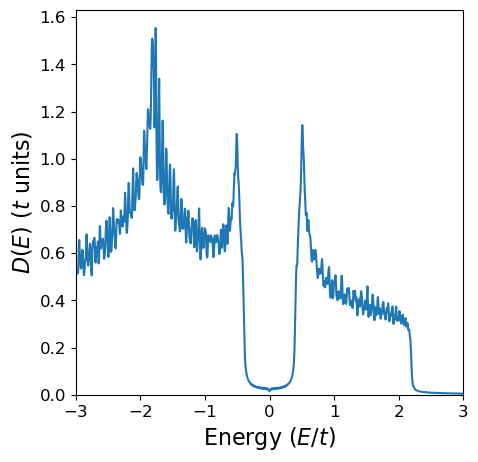

In [15]:
plt.figure(figsize=(5,5))
plt.plot(energies, dos_values_uu1)
plt.ylim(0, None)
plt.xlim(-3,3)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

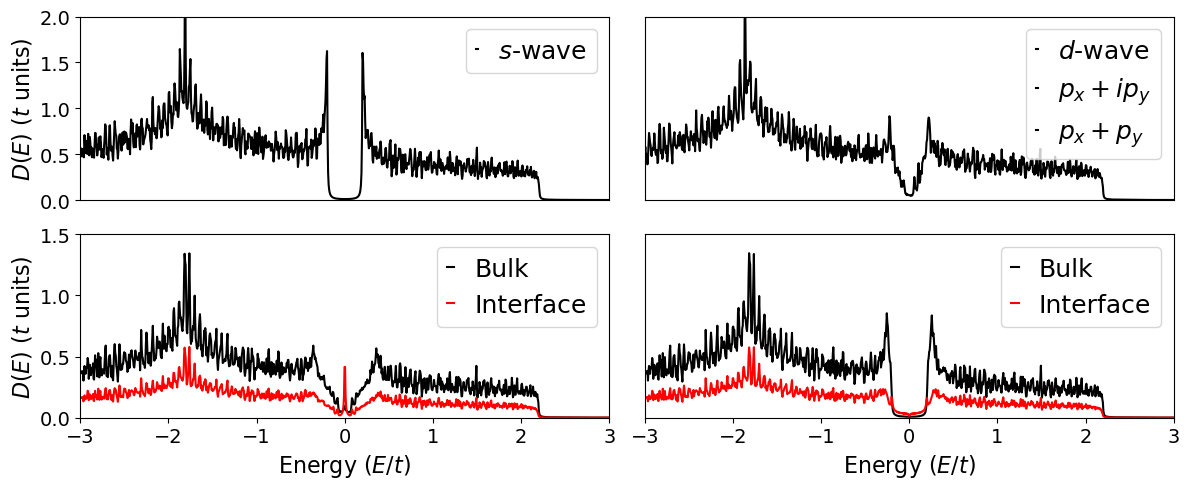

In [19]:
fig, axs = plt.subplots(2, 2, figsize=(12, 5))
axs[0][0].plot(energies, dos_values, color='k', label=r'$s$-wave')
axs[0][0].set_ylim(0, 2)
axs[0][0].set_xlim(-3,3)
axs[0][0].set_ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
axs[0][0].set_xticks([])
axs[0][0].tick_params(axis='y', labelsize=14)
axs[0][0].legend(fontsize=18, handlelength=0.1)

axs[0][1].plot(energies, dos_values4, color='k', label=r'$d$-wave')
axs[0][1].plot([], [], color='k', label=r'$p_x+ip_y$')
axs[0][1].plot([], [], color='k', label=r'$p_x+p_y$')
axs[0][1].set_ylim(0, 2)
axs[0][1].set_xlim(-3,3)
axs[0][1].set_xticks([])
axs[0][1].set_yticks([])
axs[0][1].tick_params(axis='y', labelsize=14)
axs[0][1].legend(fontsize=18, handlelength=0.1)

axs[1][0].plot(energies, 2 * dos_values_bulk2/N, color='k', label=r'Bulk')
axs[1][0].plot(energies, 2 * dos_values_interface2/N, color='r', label=r'Interface')
axs[1][0].set_ylim(0, 1.5)
axs[1][0].set_yticks([0, 0.5, 1, 1.5])
axs[1][0].set_xlim(-3,3)
axs[1][0].set_ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
axs[1][0].tick_params(axis='x', labelsize=14)
axs[1][0].tick_params(axis='y', labelsize=14)
axs[1][0].legend(fontsize=18, handlelength=0.3)
axs[1][0].set_xlabel(r'Energy ($E/t$)', fontsize=16)

axs[1][1].plot(energies, 2 * dos_bulk/N, color='k', label=r'Bulk')
axs[1][1].plot(energies, 2 * dos_interface/N, color='r', label=r'Interface')
axs[1][1].set_ylim(0, 1.5)
axs[1][1].set_xlim(-3,3)
axs[1][1].tick_params(axis='x', labelsize=14)
axs[1][1].tick_params(axis='y', labelsize=14)
axs[1][1].set_yticks([])
axs[1][1].legend(fontsize=18, handlelength=0.3)
axs[1][1].set_xlabel(r'Energy ($E/t$)', fontsize=16)

plt.tight_layout()
plt.savefig('../figures/dos.svg', bbox_inches='tight')
plt.show()

In [18]:
X, Y = 100,100
lattice = Lattice(X, Y)
N= X*Y

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 1e-8
U0 = 0 * t
U = U0 * np.ones(lattice.X)
V0 = 5 * t 
V = V0 * np.ones(lattice.X)
V_prime = V
H = Hamiltonian(t, mu, lattice, 
                V=V, V_prime=None,
                F_init=[0.9, 0.9, -0.9, -0.9])

In [19]:
energies = np.linspace(-10,10,2000) 
dos_values = 2 * H.dos(energies, eta=0.005)/ N

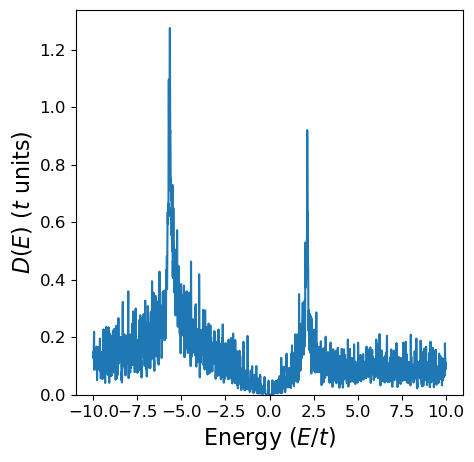

In [20]:
plt.figure(figsize=(5,5))
plt.plot(energies, dos_values)
plt.ylim(0, None)
# plt.xlim(-5,5)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()